# ATM Cash Demand Prediction
Predicting next-day ATM cash demand using Linear Regression.

**Dataset:** `atm_cash_management_dataset.csv`
Columns: ATM_ID, Date, Day_of_Week, Time_of_Day, Total_Withdrawals, Total_Deposits, Location_Type, Holiday_Flag, Special_Event_Flag, Previous_Day_Cash_Level, Weather_Condition, Nearby_Competitor_ATMs -> Cash_Demand_Next_Day

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import pickle
import warnings
warnings.filterwarnings('ignore')


## 1. Load Data

In [29]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Datasets/atm_cash_management_dataset.csv')
data.head()


,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784


In [31]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ATM_ID                   5658 non-null   object
 1   Date                     5658 non-null   object
 2   Day_of_Week              5658 non-null   object
 3   Time_of_Day              5658 non-null   object
 4   Total_Withdrawals        5658 non-null   int64 
 5   Total_Deposits           5658 non-null   int64 
 6   Location_Type            5658 non-null   object
 7   Holiday_Flag             5658 non-null   int64 
 8   Special_Event_Flag       5658 non-null   int64 
 9   Previous_Day_Cash_Level  5658 non-null   int64 
 10  Weather_Condition        5658 non-null   object
 11  Nearby_Competitor_ATMs   5658 non-null   int64 
 12  Cash_Demand_Next_Day     5658 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 574.8+ KB


In [32]:
data.isnull().sum()


,0
ATM_ID,0
Date,0
Day_of_Week,0
Time_of_Day,0
Total_Withdrawals,0
Total_Deposits,0
Location_Type,0
Holiday_Flag,0
Special_Event_Flag,0
Previous_Day_Cash_Level,0


In [33]:
data[data.duplicated()]


,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day


In [34]:
data.describe()


,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
count,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000
mean,49808.106928,10129.078473,0.022093,0.096501,100283.994698,2.477731,43085.207494
std,14903.539241,4878.853583,0.146998,0.295303,20122.365608,1.719487,16797.100086
min,1380.000000,0.000000,0.000000,0.000000,23266.000000,0.000000,0.000000
25%,39469.250000,6765.000000,0.000000,0.000000,86533.500000,1.000000,31558.750000
50%,50039.000000,10048.000000,0.000000,0.000000,100276.500000,2.000000,42589.500000
75%,60132.500000,13430.000000,0.000000,0.000000,113956.500000,4.000000,53831.000000
max,107790.000000,32395.000000,1.000000,1.000000,172227.000000,5.000000,114724.000000


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

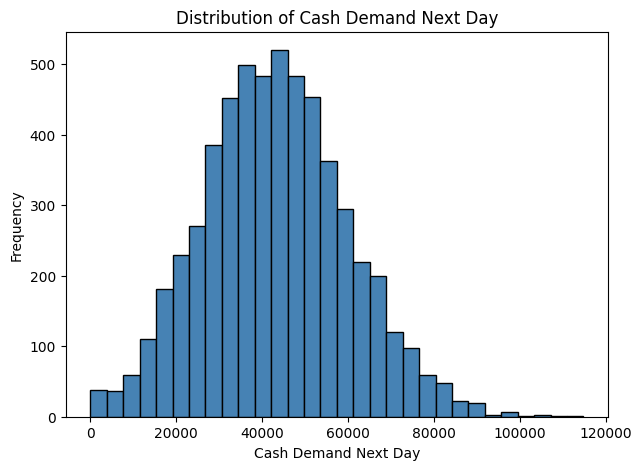

Skewness: 0.20148792883757027
Kurtosis: 0.02541410303385172


In [35]:
plt.figure(figsize=(7, 5))
plt.hist(data['Cash_Demand_Next_Day'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Cash Demand Next Day")
plt.ylabel("Frequency")
plt.title("Distribution of Cash Demand Next Day")
plt.show()

print("Skewness:", data['Cash_Demand_Next_Day'].skew())
print("Kurtosis:", data['Cash_Demand_Next_Day'].kurt())


### 2.2 Target Variable Boxplot (Outlier Check)

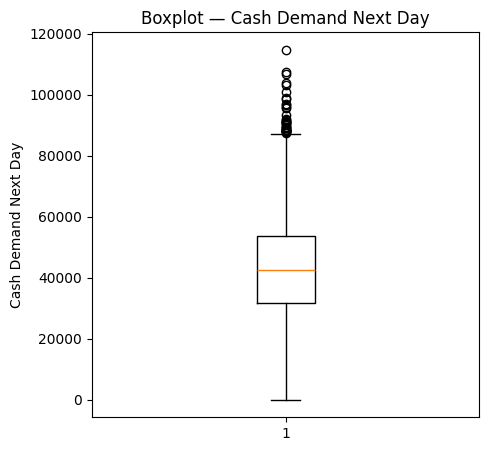

Number of outliers (IQR method): 36


In [36]:
plt.figure(figsize=(5, 5))
plt.boxplot(data['Cash_Demand_Next_Day'], vert=True)
plt.ylabel("Cash Demand Next Day")
plt.title("Boxplot — Cash Demand Next Day")
plt.show()

q1 = data['Cash_Demand_Next_Day'].quantile(0.25)
q3 = data['Cash_Demand_Next_Day'].quantile(0.75)
iqr = q3 - q1
outliers = data[(data['Cash_Demand_Next_Day'] < q1 - 1.5*iqr) | (data['Cash_Demand_Next_Day'] > q3 + 1.5*iqr)]
print("Number of outliers (IQR method):", len(outliers))


### 2.3 Distributions of Key Numeric Features

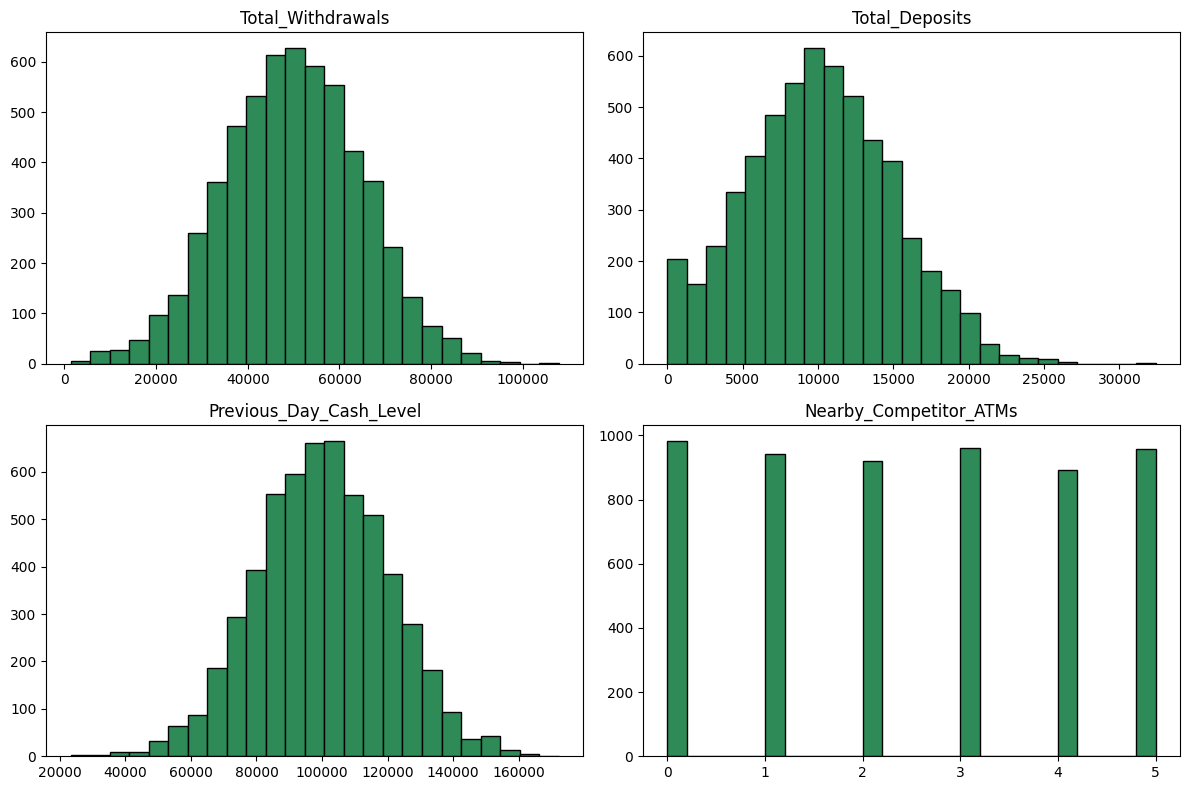

In [37]:
num_cols = ['Total_Withdrawals', 'Total_Deposits', 'Previous_Day_Cash_Level', 'Nearby_Competitor_ATMs']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=25, color='seagreen', edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


### 2.4 Correlation Heatmap

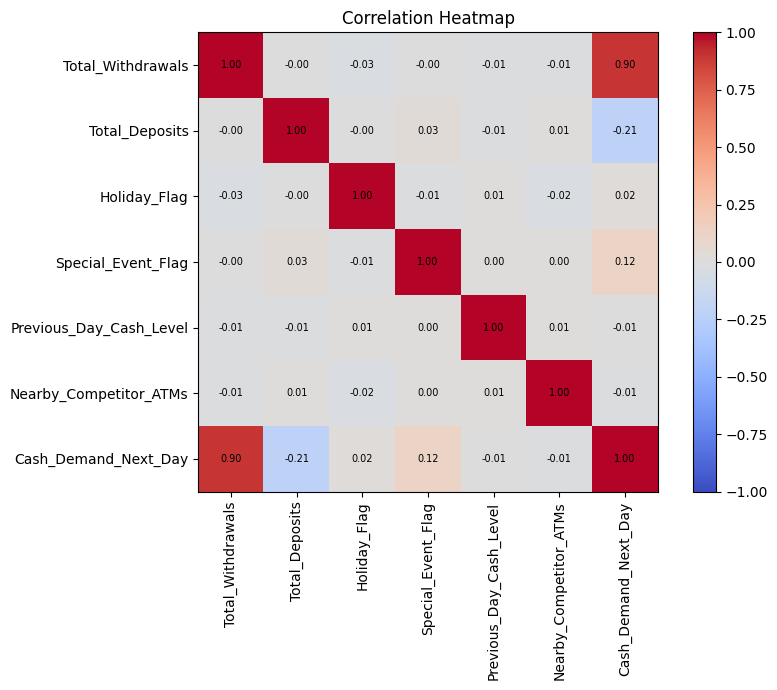

In [38]:
plt.figure(figsize=(9, 7))
corr = data.corr(numeric_only=True)
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 2.5 Correlation with Target (Ranked)

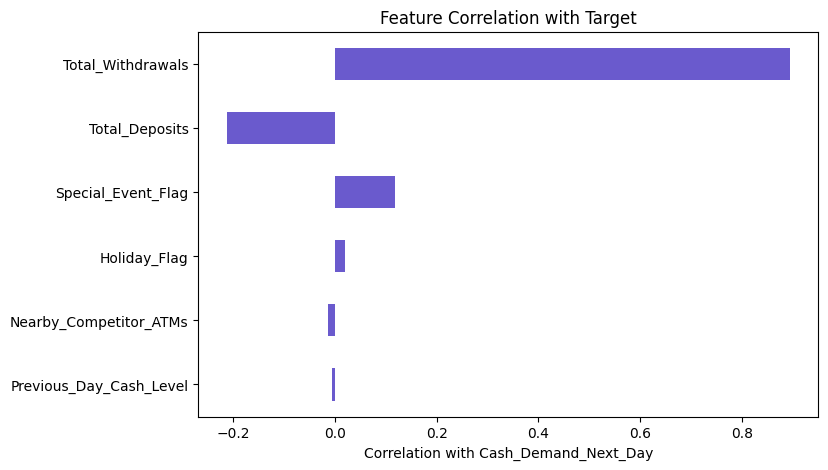

,Cash_Demand_Next_Day
Total_Withdrawals,0.895053
Total_Deposits,-0.213557
Special_Event_Flag,0.117524
Holiday_Flag,0.019698
Nearby_Competitor_ATMs,-0.014231
Previous_Day_Cash_Level,-0.005849


In [39]:
target_corr = data.corr(numeric_only=True)['Cash_Demand_Next_Day'].drop('Cash_Demand_Next_Day').sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind='barh', color='slateblue')
plt.xlabel("Correlation with Cash_Demand_Next_Day")
plt.title("Feature Correlation with Target")
plt.gca().invert_yaxis()
plt.show()
target_corr


### 2.6 Scatter — Total Withdrawals vs Cash Demand Next Day

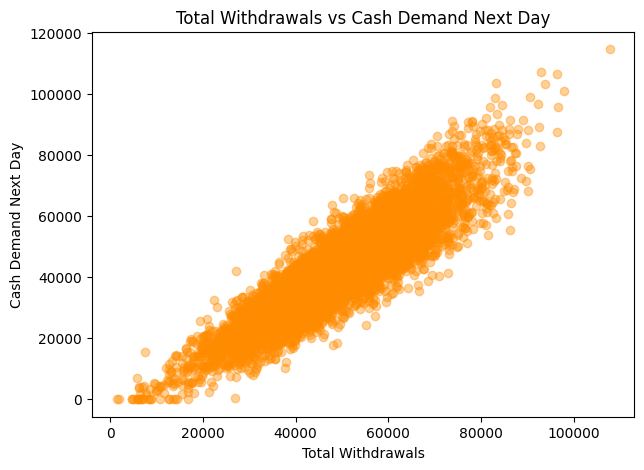

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(data['Total_Withdrawals'], data['Cash_Demand_Next_Day'], alpha=0.4, color='darkorange')
plt.xlabel("Total Withdrawals")
plt.ylabel("Cash Demand Next Day")
plt.title("Total Withdrawals vs Cash Demand Next Day")
plt.show()


### 2.7 Scatter — Previous Day Cash Level vs Cash Demand Next Day

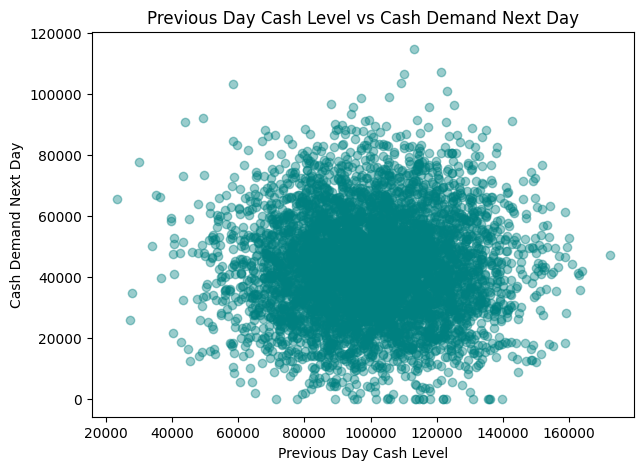

In [41]:
plt.figure(figsize=(7, 5))
plt.scatter(data['Previous_Day_Cash_Level'], data['Cash_Demand_Next_Day'], alpha=0.4, color='teal')
plt.xlabel("Previous Day Cash Level")
plt.ylabel("Cash Demand Next Day")
plt.title("Previous Day Cash Level vs Cash Demand Next Day")
plt.show()


### Comparison 1 — Day of Week vs Cash Demand Next Day

<Figure size 900x500 with 0 Axes>

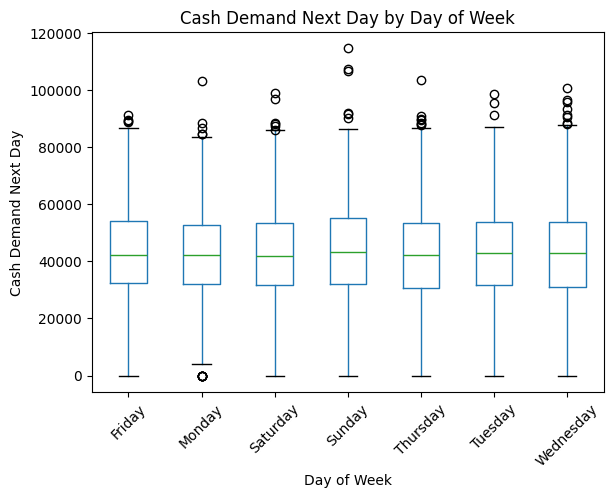

Day_of_Week
Monday       42650.046931
Tuesday      43328.164366
Wednesday    43133.503896
Thursday     42839.079462
Friday       43175.278729
Saturday     42809.879012
Sunday       43676.686732
Name: Cash_Demand_Next_Day, dtype: float64


In [42]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(9, 5))
data.boxplot(column='Cash_Demand_Next_Day', by='Day_of_Week', grid=False)
plt.xlabel("Day of Week")
plt.ylabel("Cash Demand Next Day")
plt.title("Cash Demand Next Day by Day of Week")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

print(data.groupby('Day_of_Week')['Cash_Demand_Next_Day'].mean().reindex(order))


### Comparison 2 — Holiday vs Non-Holiday

<Figure size 600x500 with 0 Axes>

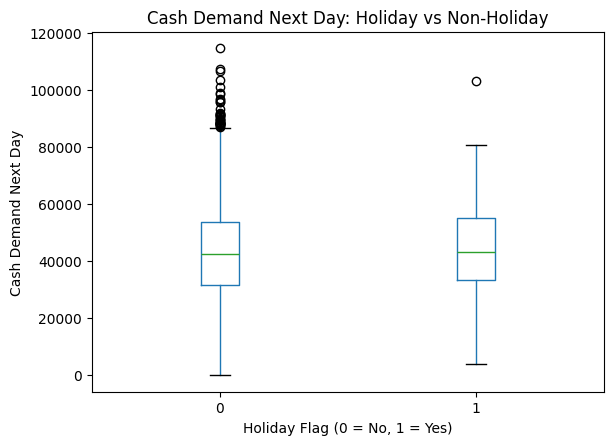

Holiday_Flag
0    43035.481475
1    45286.280000
Name: Cash_Demand_Next_Day, dtype: float64


In [43]:
plt.figure(figsize=(6, 5))
data.boxplot(column='Cash_Demand_Next_Day', by='Holiday_Flag', grid=False)
plt.xlabel("Holiday Flag (0 = No, 1 = Yes)")
plt.ylabel("Cash Demand Next Day")
plt.title("Cash Demand Next Day: Holiday vs Non-Holiday")
plt.suptitle("")
plt.show()

print(data.groupby('Holiday_Flag')['Cash_Demand_Next_Day'].mean())


### 2.8 Location Type vs Cash Demand Next Day

<Figure size 700x500 with 0 Axes>

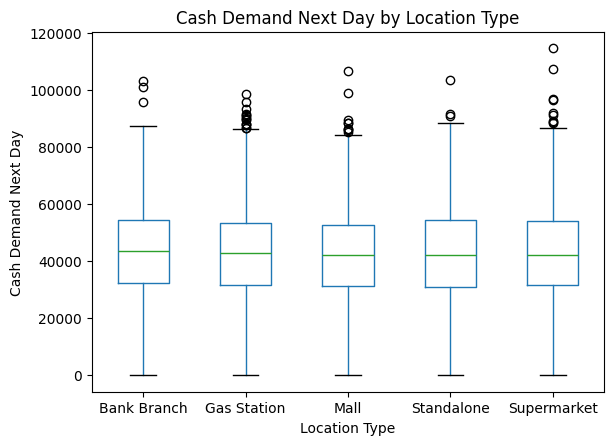

Location_Type
Bank Branch    43617.276316
Gas Station    43112.919580
Mall           42423.671208
Standalone     42777.797723
Supermarket    43475.262599
Name: Cash_Demand_Next_Day, dtype: float64


In [44]:
plt.figure(figsize=(7, 5))
data.boxplot(column='Cash_Demand_Next_Day', by='Location_Type', grid=False)
plt.xlabel("Location Type")
plt.ylabel("Cash Demand Next Day")
plt.title("Cash Demand Next Day by Location Type")
plt.suptitle("")
plt.show()

print(data.groupby('Location_Type')['Cash_Demand_Next_Day'].mean())


## 3. Encode Categorical Features
`Day_of_Week`, `Time_of_Day`, `Location_Type`, and `Weather_Condition` are text categories, so they're one-hot encoded before modeling.

In [45]:
cat_cols = ['Day_of_Week', 'Time_of_Day', 'Location_Type', 'Weather_Condition']
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
data_encoded.head()


,ATM_ID,Date,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day,Day_of_Week_Monday,...,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Location_Type_Gas Station,Location_Type_Mall,Location_Type_Standalone,Location_Type_Supermarket,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Snowy
0,ATM_0041,2022-04-25,57450,9308,0,0,112953,5,44165,True,...,False,True,False,False,False,True,False,False,True,False
1,ATM_0007,2023-11-24,72845,17896,0,0,115348,0,41249,False,...,False,True,False,False,False,False,True,False,False,False
2,ATM_0014,2022-08-27,42957,12712,0,0,90731,1,29901,False,...,False,True,False,False,False,False,True,True,False,False
3,ATM_0029,2023-08-27,43014,1375,0,0,88754,5,44155,False,...,True,False,False,False,True,False,False,False,True,False
4,ATM_0028,2022-12-15,36379,2938,0,0,129312,0,29784,False,...,True,False,False,False,False,False,False,False,False,True


## 4. Feature / Target Split

In [46]:
drop_cols = ['ATM_ID', 'Date', 'Cash_Demand_Next_Day']
feature_cols = [c for c in data_encoded.columns if c not in drop_cols]

X = data_encoded[feature_cols]
y = data_encoded['Cash_Demand_Next_Day']
X.head()


,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,...,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Location_Type_Gas Station,Location_Type_Mall,Location_Type_Standalone,Location_Type_Supermarket,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Snowy
0,57450,9308,0,0,112953,5,True,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1,72845,17896,0,0,115348,0,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,42957,12712,0,0,90731,1,False,True,False,False,...,False,True,False,False,False,False,True,True,False,False
3,43014,1375,0,0,88754,5,False,False,True,False,...,True,False,False,False,True,False,False,False,True,False
4,36379,2938,0,0,129312,0,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Linear Regression Model

In [48]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

pred_train = model.predict(X_train_scaled)
pred_test = model.predict(X_test_scaled)

metrics = {
    "Train R2": r2_score(y_train, pred_train),
    "Test R2": r2_score(y_test, pred_test),
    "Test MAE": mean_absolute_error(y_test, pred_test),
    "Test RMSE": mean_squared_error(y_test, pred_test) ** 0.5,
    "Test MAPE %": mean_absolute_percentage_error(y_test, pred_test) * 100,
}
pd.DataFrame([metrics])


,Train R2,Test R2,Test MAE,Test RMSE,Test MAPE %
0,0.863693,0.870465,5043.14583,6112.522797,4.121486e+18


## 6. Actual vs Predicted

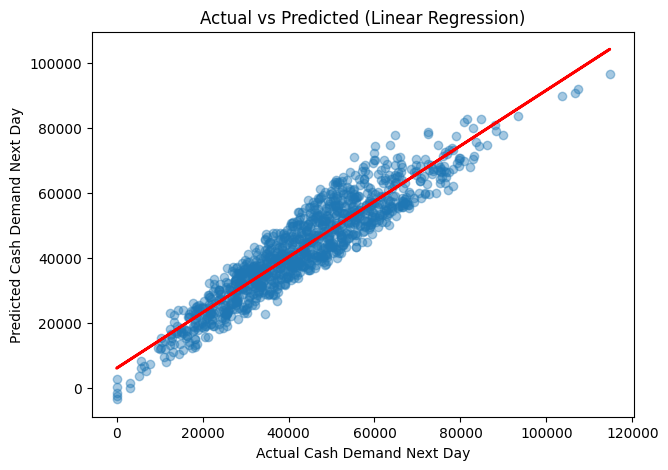

Slope: 0.8563872497108348   Intercept: 5968.941218273819


In [49]:
y_pred = pred_test

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
m, c = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + c, 'r', linewidth=2)
plt.xlabel("Actual Cash Demand Next Day")
plt.ylabel("Predicted Cash Demand Next Day")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

print("Slope:", m, "  Intercept:", c)


### Residual Plot

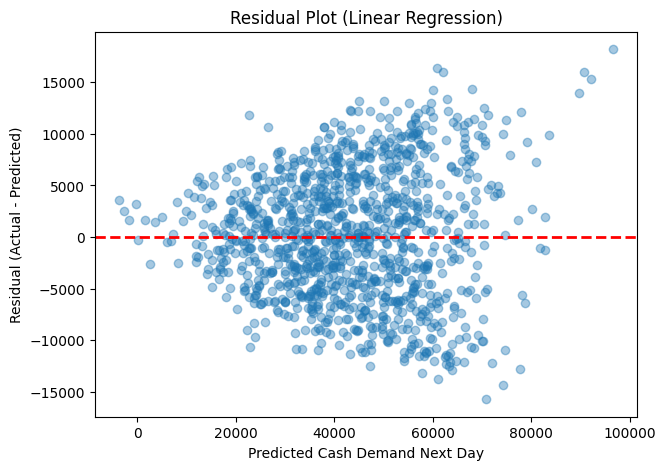

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Cash Demand Next Day")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.show()


## 7. Feature Coefficients

In [51]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_,
}).sort_values("Coefficient", key=abs, ascending=False)
importance_df


,Feature,Coefficient
0,Total_Withdrawals,14993.829146
1,Total_Deposits,-3628.594576
3,Special_Event_Flag,2166.369410
2,Holiday_Flag,825.223060
16,Location_Type_Mall,214.410247
19,Weather_Condition_Cloudy,212.322062
21,Weather_Condition_Snowy,190.874449
20,Weather_Condition_Rainy,174.125766
13,Time_of_Day_Morning,-135.578103
10,Day_of_Week_Tuesday,-126.171761


## 8. Save Model (Single Pickle File)

In [52]:
with open('atm_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'scaler': scaler,
        'feature_cols': feature_cols
    }, f)

print("Saved: atm_model.pkl")


Saved: atm_model.pkl


## 9. Predict on New Data

In [53]:
with open('atm_model.pkl', 'rb') as f:
    saved = pickle.load(f)

# Example new observation - replace with real values as needed
new_row = {
    "Total_Withdrawals": 57450,
    "Total_Deposits": 9308,
    "Holiday_Flag": 0,
    "Special_Event_Flag": 0,
    "Previous_Day_Cash_Level": 112953,
    "Nearby_Competitor_ATMs": 5,
    "Day_of_Week": "Monday",
    "Time_of_Day": "Morning",
    "Location_Type": "Standalone",
    "Weather_Condition": "Rainy",
}
new_sample = pd.DataFrame([new_row])
new_sample = pd.get_dummies(new_sample, columns=['Day_of_Week', 'Time_of_Day', 'Location_Type', 'Weather_Condition'])
new_sample = new_sample.reindex(columns=saved['feature_cols'], fill_value=0)

new_sample_scaled = saved['scaler'].transform(new_sample)
prediction = saved['model'].predict(new_sample_scaled)
print("Predicted Cash Demand Next Day:", prediction[0])


Predicted Cash Demand Next Day: 50288.77941369336


## 10. Predictions on Full Test Set

In [54]:
predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})
predictions_df["Abs_Error"] = (predictions_df["Actual"] - predictions_df["Predicted"]).abs()
predictions_df.reset_index(drop=True, inplace=True)
predictions_df


,Actual,Predicted,Abs_Error
0,50335,44534.316353,5800.683647
1,76882,71871.729977,5010.270023
2,49730,43334.860273,6395.139727
3,26431,30051.962845,3620.962845
4,26694,25697.593747,996.406253
...,...,...,...
1127,29138,30238.373726,1100.373726
1128,42751,40862.523939,1888.476061
1129,61086,56653.151126,4432.848874
1130,52623,43814.327754,8808.672246


## Summary
EDA highlights which factors (withdrawal volume, previous-day cash level, day of week, holidays, location type) most influence next-day cash demand. Categorical features are one-hot encoded, and a single Linear Regression model — trained on scaled features — is used for prediction, saved to `atm_model.pkl`.